In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [7]:
df = pd.read_csv("customer_data.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              100 non-null    int64 
 1   Gender                  100 non-null    object
 2   Age                     100 non-null    int64 
 3   Annual Income (k$)      100 non-null    int64 
 4   Spending Score (1-100)  100 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

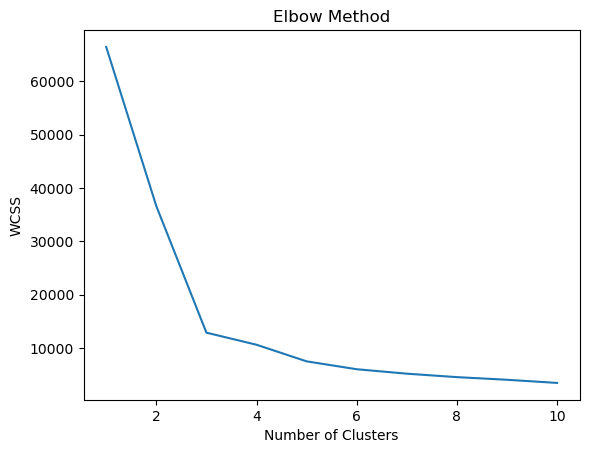

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=0)
y_kmeans = kmeans.fit_predict(X)

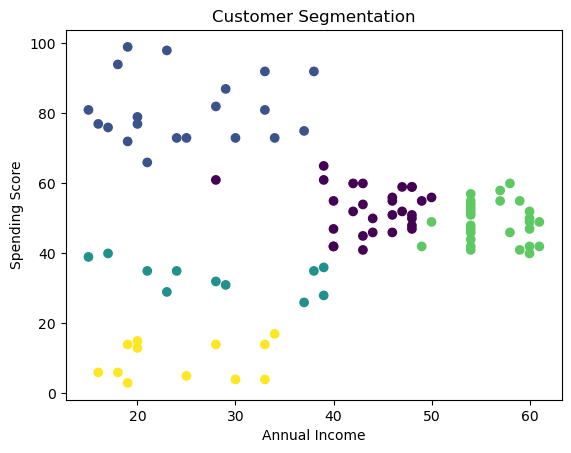

In [13]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [14]:
print(kmeans.cluster_centers_)

[[43.96551724 52.5862069 ]
 [24.95       81.        ]
 [28.18181818 33.27272727]
 [56.32142857 48.82142857]
 [24.58333333  9.58333333]]


In [18]:
import pandas as pd
from sklearn.cluster import KMeans
import pickle

df = pd.read_csv("customer_data.csv")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)


with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model saved successfully!")

Model saved successfully!


In [19]:
from flask import Flask, request, jsonify
import pickle
import numpy as np

# Load model
with open("kmeans_model.pkl", "rb") as f:
    model = pickle.load(f)

app = Flask(__name__)

@app.route('/')
def home():
    return "KMeans Model API is running!"

# Prediction API
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()

    income = data['income']
    score = data['score']

    features = np.array([[income, score]])
    cluster = model.predict(features)

    return jsonify({"cluster": int(cluster[0])})

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\sreeb\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [20]:
app.py

AttributeError: 'Flask' object has no attribute 'py'